In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import pickle

In [4]:
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [6]:
label_encod_gender = LabelEncoder()
data['Gender']=label_encod_gender.fit_transform(data['Gender'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [7]:
onehot_enco_geo = OneHotEncoder(handle_unknown='ignore')
geo_enco = onehot_enco_geo.fit_transform(data[['Geography']]).toarray()
geo_enco_df = pd.DataFrame(geo_enco,columns=onehot_enco_geo.get_feature_names_out(['Geography']))
##geo_encoded_df = pd.DataFrame(geo_encoded, columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_enco_df


,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [8]:
data = pd.concat([data.drop('Geography', axis=1),geo_enco_df],axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [9]:
X = data.drop(['EstimatedSalary'], axis=1)
y = data['EstimatedSalary']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2, random_state=42)


In [ ]:
scaler1 = StandardScaler()
X_train = scaler1.fit_transform(X_train)
X_test = scaler1.transform(X_test)


In [ ]:
import pickle

with open('label_encod_gender.pkl', 'wb') as file:
##√√with open('label_encoder_gender.pkl', 'wb') as file:
    pickle.dump(label_encod_gender,file)

with open('onehot_enco_geo.pkl', 'wb') as file:
    pickle.dump(onehot_enco_geo, file)

with open('scaler1.pkl', 'wb') as file:
    pickle.dump(scaler1, file)

In [13]:
# Build the model
from keras.models import Sequential
from keras.layers import Dense


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

## compile the model
model.compile(optimizer='adam',loss='mean_absolute_error',metrics=['mae'])

model.summary()



2025-05-01 11:40:11.657820: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/admin/.pyenv/versions/3.10.13/envs/tf-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

# Set up TensorBoard
log_dir = "regressionlogs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [15]:
# Set up Early Stopping
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [25]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[early_stopping_callback, tensorboard_callback]
    
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48824.9336 - mae: 48824.9336 - val_loss: 50350.8242 - val_mae: 50350.8242
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50271.3398 - mae: 50271.3398 - val_loss: 50353.1445 - val_mae: 50353.1445
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 49434.6680 - mae: 49434.6680 - val_loss: 50352.1289 - val_mae: 50352.1289
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 50897.7969 - mae: 50897.7969 - val_loss: 50342.7344 - val_mae: 50342.7344
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48428.5156 - mae: 48428.5156 - val_loss: 50337.8945 - val_mae: 50337.8945
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 49819.3906 - mae: 49819.3906 - val_loss: 50340.6133 - val_mae: 50340.6133
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48565.7344 - mae: 48565.7344 - val_loss: 50336.0977 - val_mae: 50336.0977
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50158.0273

In [28]:
##%load_ext tensorboard

In [29]:
##%tensorboard --logdir regressionlogs/fit    

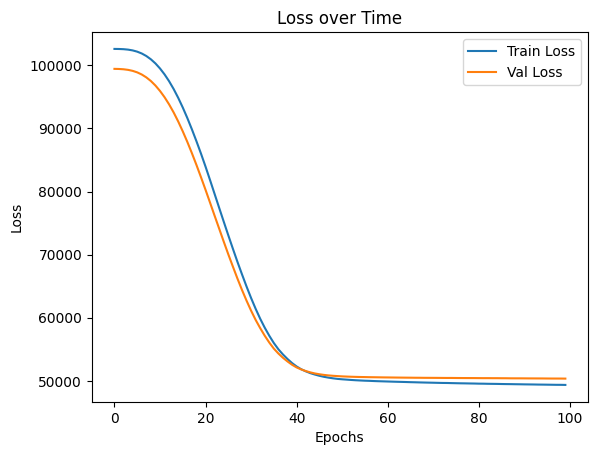

In [22]:
    import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Time')
plt.show()      

In [23]:
# Make sure X_test and y_test are both the same length
print(X_test.shape)  # should be (2000, ...) if y_test has 2000 samples
print(y_test.shape)

# Then evaluate
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {test_mae}')


(8000, 12)
(8000,)
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 50591.6406 - mae: 50591.6406
Test MAE: 50354.7578125


In [26]:
model.save('regression_model.h5')